In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import joblib


In [ ]:
# Load dataset
df = pd.read_csv("/content/updated_pollution_dataset.csv")

# Display first rows
df.head()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [ ]:
df['Temperature'].unique()

array([29.8, 28.3, 23.1, 27.1, 26.5, 39.4, 41.7, 31. , 29.4, 33.2, 26.3,
       32.5, 20. , 28.6, 22.3, 32. , 22.9, 37.6, 34.7, 37.8, 27.6, 25.6,
       24.6, 26.2, 22.6, 30. , 29.6, 52.5, 44.7, 23.3, 35.4, 29.7, 21.8,
       27.7, 27.5, 28. , 22.2, 33.3, 37.5, 30.9, 39.3, 24.7, 27.8, 17.4,
       18.1, 22.4, 25.3, 42.1, 32.6, 46.1, 33.5, 48.1, 31.6, 29. , 24.9,
       20.8, 28.2, 21.5, 17.5, 58.6, 28.1, 25. , 25.7, 35.1, 26.7, 20.4,
       25.9, 22.1, 34.1, 30.4, 41.4, 25.5, 36.6, 18.8, 34.9, 23. , 21.4,
       32.3, 33.1, 29.9, 29.3, 23.9, 23.7, 21.9, 44.9, 27. , 49.6, 33.4,
       23.5, 41.5, 21. , 31.3, 46.8, 24.1, 22.5, 29.5, 33. , 30.1, 27.4,
       30.8, 36.2, 32.8, 21.6, 31.4, 24.2, 47.3, 40. , 29.2, 20.1, 42.6,
       33.7, 30.7, 37.3, 28.9, 25.2, 30.2, 35.6, 32.4, 35. , 15.4, 22.8,
       34.4, 23.2, 30.5, 24. , 32.1, 14.1, 28.8, 31.1, 38.1, 33.6, 24.5,
       28.7, 38.3, 25.1, 32.9, 26.1, 43.1, 29.1, 28.4, 34.5, 23.4, 36.4,
       26.4, 38.7, 50.9, 26. , 47.2, 35.8, 31.7, 39

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
df.isnull().sum()


,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


In [ ]:
df.describe()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


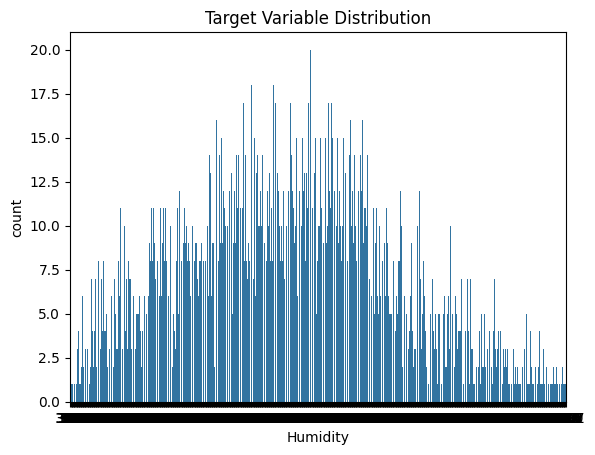

In [ ]:
sns.countplot(x="Humidity", data=df)
plt.title("Target Variable Distribution")
plt.show()


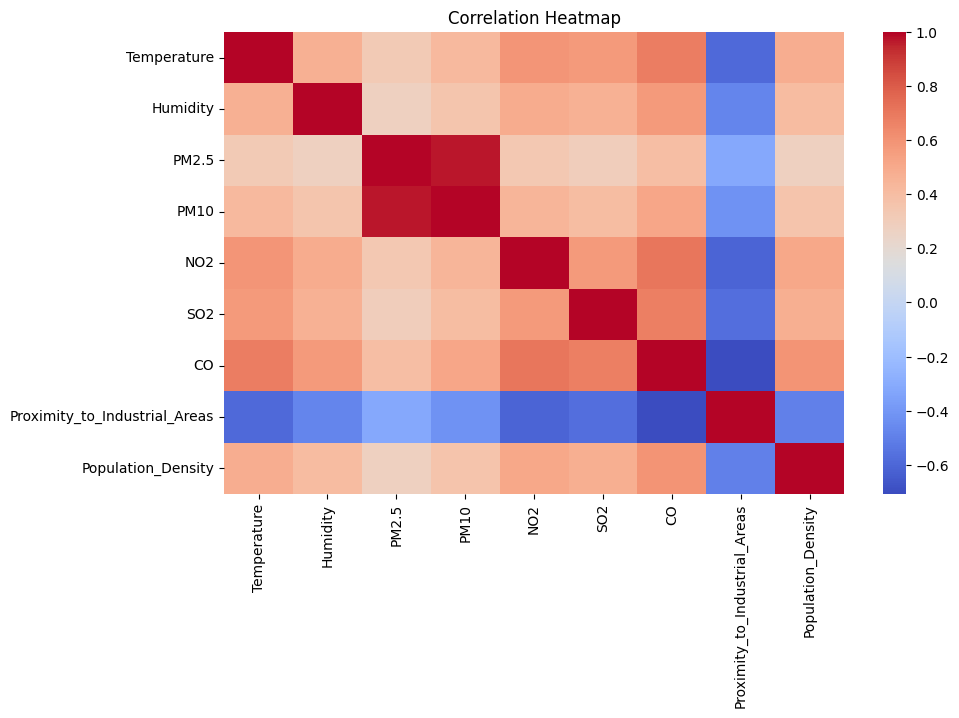

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Air Quality', axis=1).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Air Quality", axis=1)
y = df["Air Quality"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())


Before SMOTE: Air Quality
Good         1600
Moderate     1200
Poor          800
Hazardous     400
Name: count, dtype: int64
After SMOTE: Air Quality
Good         1600
Poor         1600
Hazardous    1600
Moderate     1600
Name: count, dtype: int64


In [ ]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X.shape[1])
print("Reduced Features:", X_train_pca.shape[1])


Original Features: 9
Reduced Features: 7


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train_pca, y_train_smote)


DecisionTreeClassifier(max_depth=8, random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.906

Classification Report:
               precision    recall  f1-score   support

        Good       0.98      0.98      0.98       400
   Hazardous       0.79      0.84      0.81       100
    Moderate       0.91      0.90      0.91       300
        Poor       0.81      0.80      0.80       200

    accuracy                           0.91      1000
   macro avg       0.87      0.88      0.88      1000
weighted avg       0.91      0.91      0.91      1000



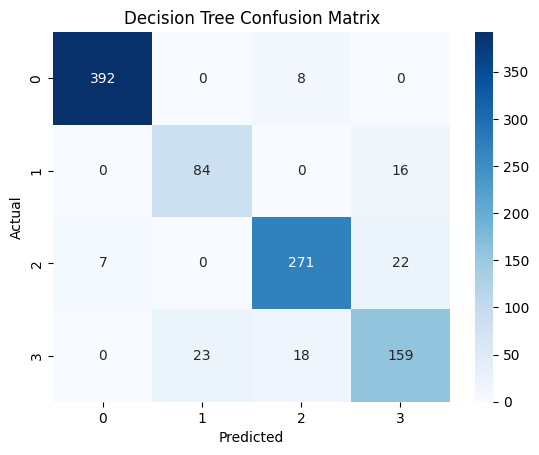

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
def predict_pollution(sample):
    sample_scaled = scaler.transform(sample)
    sample_pca = pca.transform(sample_scaled)
    result = dt_model.predict(sample_pca)
    return result

# Example usage:
# new_data = pd.DataFrame([[45, 78, 120, 35]], columns=X.columns)
# print(predict_pollution(new_data))


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# The dt_model, scaler, and pca objects are already available from previous cell executions.

# Redefine the prediction function to be used by Gradio,
# ensuring it takes individual features and processes them correctly.
def predict_air_quality(
    Temperature, Humidity, PM2_5, PM10, NO2, SO2, CO,
    Proximity_to_Industrial_Areas, Population_Density
):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[
        Temperature, Humidity, PM2_5, PM10, NO2, SO2, CO,
        Proximity_to_Industrial_Areas, Population_Density
    ]], columns=X.columns) # X.columns comes from the original DataFrame

    # Scale and apply PCA using the previously fitted scaler and pca objects
    sample_scaled = scaler.transform(input_data)
    sample_pca = pca.transform(sample_scaled)

    # Make prediction using the trained model
    result = dt_model.predict(sample_pca)
    return result[0]

# Define Gradio interface with appropriate inputs
iface = gr.Interface(
    fn=predict_air_quality,
    inputs=[
        gr.Number(label='Temperature'),
        gr.Number(label='Humidity'),
        gr.Number(label='PM2.5'),
        gr.Number(label='PM10'),
        gr.Number(label='NO2'),
        gr.Number(label='SO2'),
        gr.Number(label='CO'),
        gr.Number(label='Proximity to Industrial Areas'),
        gr.Number(label='Population Density')
    ],
    outputs='text',
    title='Air Quality Prediction',
    description='Enter the environmental parameters to predict Air Quality.'
)

# Launch the Gradio interface
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://987576f2c353251a6e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
